# Draft

In [1]:
import glob
import warnings

import ot
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance
import tifffile
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import MDS, TSNE
from sklearn.metrics import pairwise_distances
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import KMeans

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, cross_val_score, LeaveOneOut, GridSearchCV, cross_val_predict, permutation_test_score
from sklearn.feature_selection import SelectKBest, chi2, f_classif, RFECV
from sklearn.decomposition import PCA

from collections import Counter
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression

from src.repartition.data_loading import get_annotation, tif_to_real_mask
from src.repartition.data_analysis import *
from src.repartition.visualization import *
from src.repartition.constants import PROJECT_ROOT, PATH_PATIENT_DATA
from src.repartition.TissueCollection import * 
from src.repartition.geometry_funcs import *

In [2]:
%load_ext autoreload
%autoreload 1
%aimport src.repartition.data_loading, src.repartition.data_analysis, src.repartition.visualization, src.repartition.constants, src.repartition.TissueCollection, src.repartition.geometry_funcs

## Load paths

In [7]:
project_root = PROJECT_ROOT
annot_dir = project_root / 'data/repartition/annotation/'
annotations_paths = glob.glob(str(annot_dir) + "/" +'*.tif')
annotations_paths = np.array(annotations_paths)
slides_annot, puzzle_sld = get_annotation(annotations_paths, tif_to_real_mask)

In [9]:
slides_annot['BC.25P31438.0']

{'tumor': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(2704, 2023), dtype=uint8),
 'necrosis': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(2704, 2023), dtype=uint8),
 'stroma': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(2704, 2023), dtype=uint8),
 'tumor_bed': array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ...,

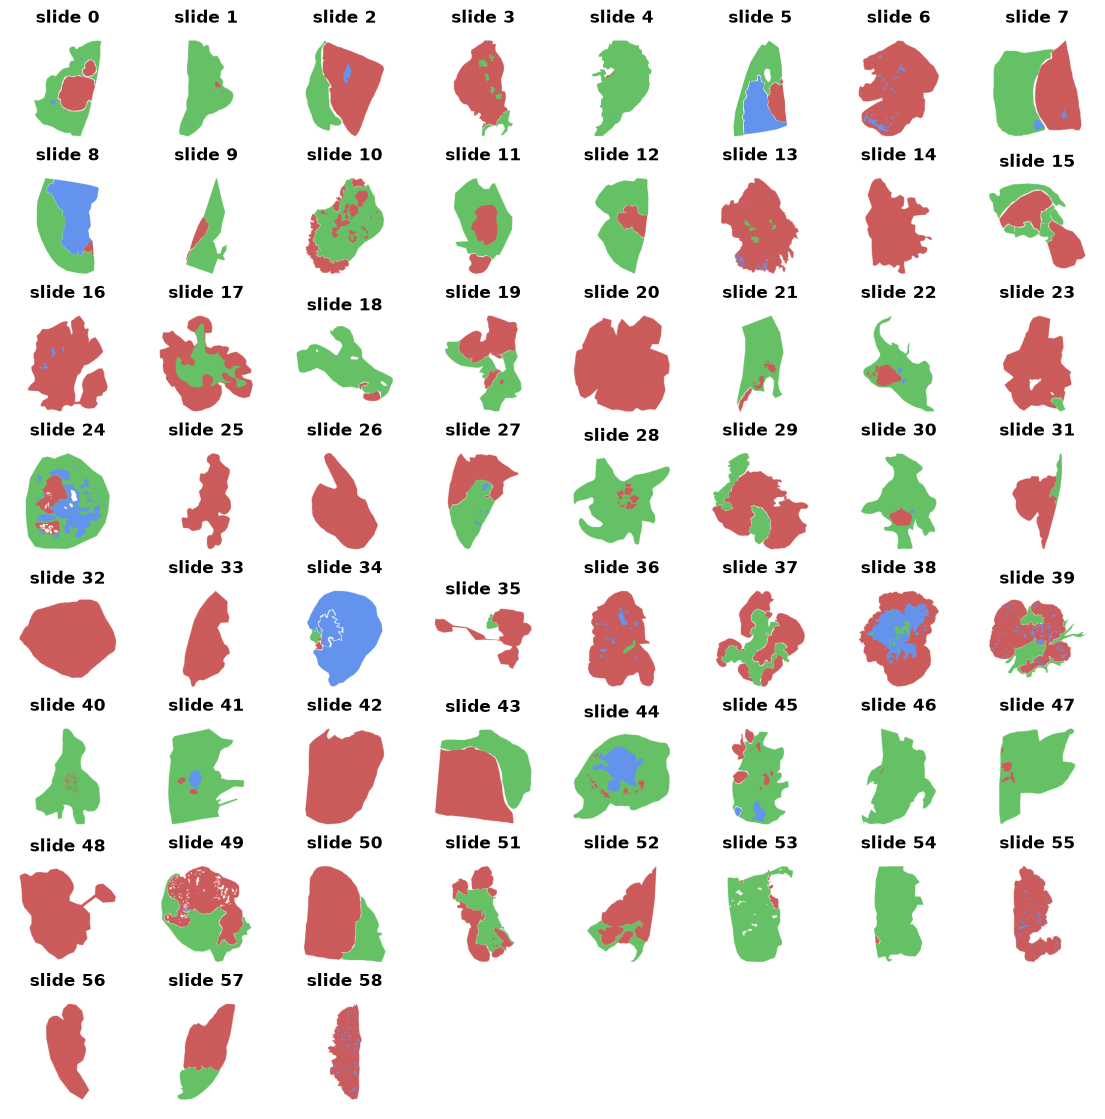

In [4]:
slides_tumor = get_tumor_slides(slides_annot)
plot_slide_grid(slides_tumor)

In [6]:
distance_data, distribution_data_local = get_tissues_data(
    slides_annot, find_center_barycentre, 
    return_kde=False, return_hist=False, 
    local_ratio=True,
)

In [11]:
sld = 'BC.25P31438.0'
export_mask_pdf(
    {sld:slides_annot[sld]},
    output="masks_tot.pdf",
    saveimg=False
)

In [12]:
export_furthest_tissue_pdf(
    slides_annot,
    find_center_barycentre, 
    distance_data, 
    tissue_type='tumor',
    output="furthest_tumors.pdf",
    saveimg=False
)

In [13]:
sp_infos = dict()
for sld_name in slides_annot:
    masks = slides_annot[sld_name]

    if not np.any(masks['tumor']):
        continue

    tumor_mask = masks['tumor']
    bed_mask = masks['tumor_bed']

    sp_score = compute_tumor_spread(tumor_mask, bed_mask)
    sp_infos.update({
        sld_name : sp_score
    })

export_tumor_spread_pdf(
    slides_annot,
    sp_infos,
    output="tumor_spread.pdf",
    saveimg=False
)

In [ ]:
all_tissue_areas = get_areas(distance_data)
export_tissues_proportion(
    all_tissue_areas, 
    draw_type='bar',
    saveimg=True,
    output='tissues_proportion.pdf',
)

In [ ]:
furthest_tum = get_furthest_tumors(distance_data, by='id-slide')
#furthest_tum.to_csv('furthest_tumors.csv')

In [10]:
specific_cases = (
    "24P40930_8_1",
    "BC.25P18234.7.7.1",
    "BC.25P16939.5.7.1",
    "BC.25P12607.7.10.8"
)

specific_distribution = {key: val for key, val in distribution_data_local.items() if key in specific_cases}


KeyboardInterrupt



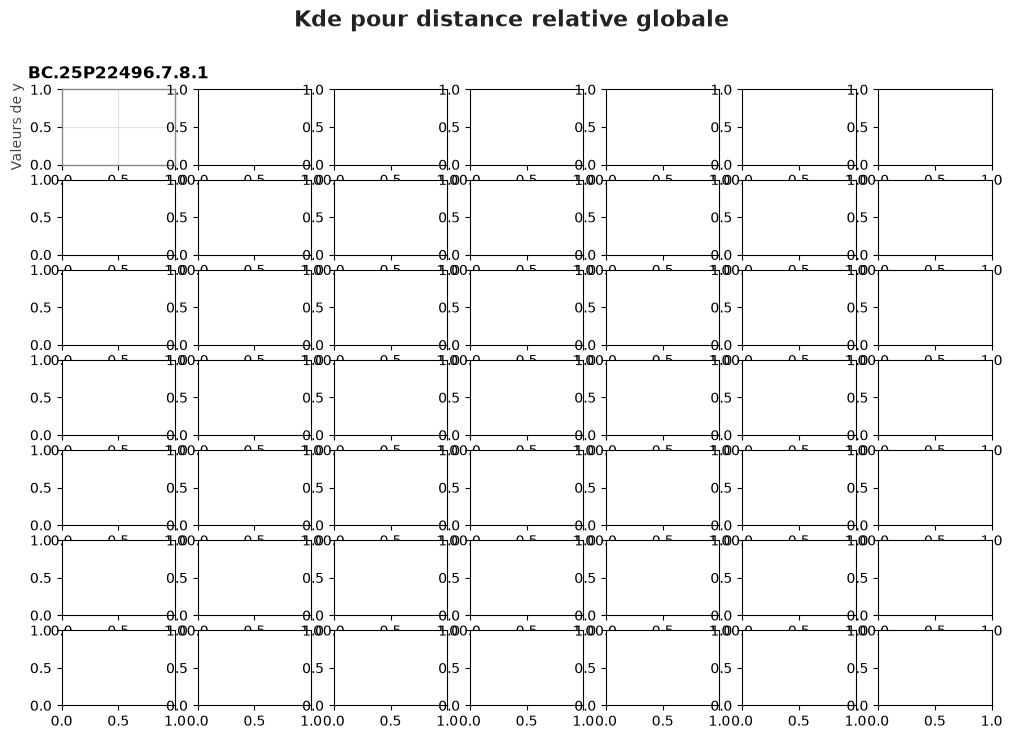

In [12]:
plot_distribution(distribution_data_local, show='kde', ref='center', suptitle="Kde pour distance relative globale")

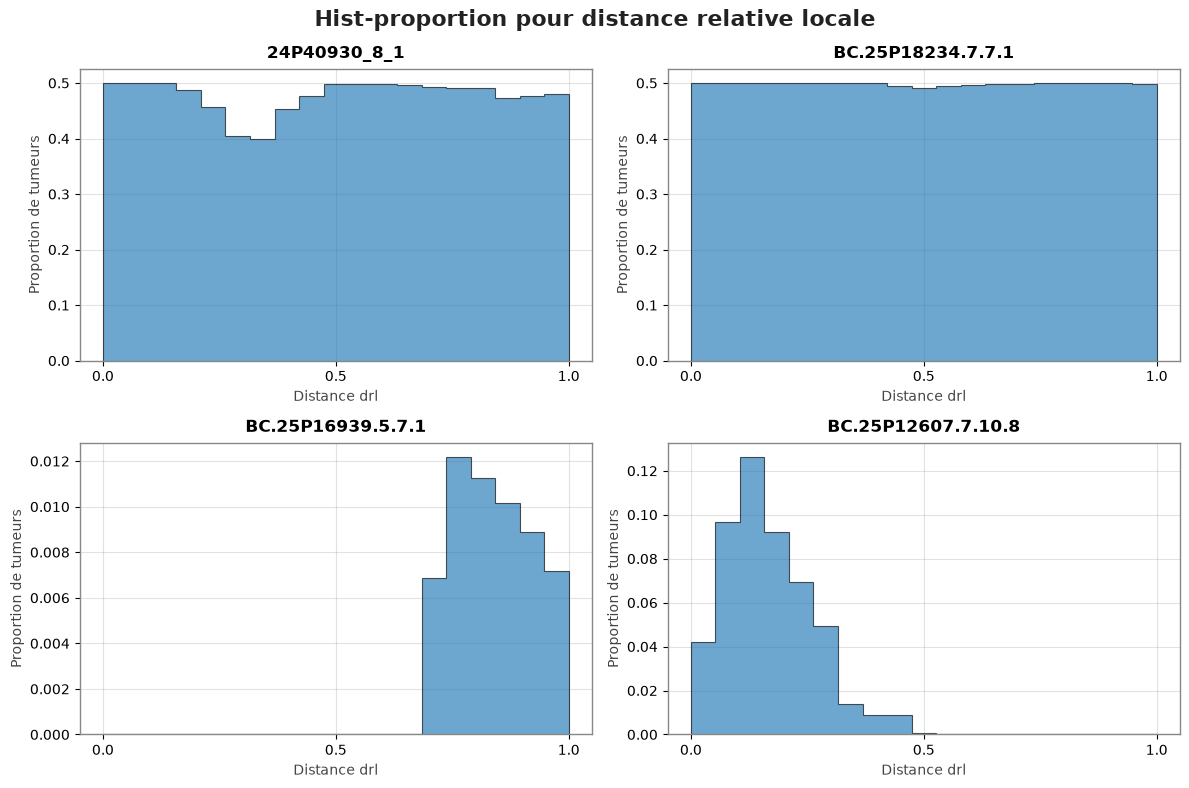

In [11]:
plot_distribution(
    specific_distribution, show='hist-proportion',
    suptitle="Hist-proportion pour distance relative locale",
    xlabel="Distance drl",
    ylabel="Proportion de tumeurs"
)

In [5]:
vect_p = get_distrib_model(model='vect', thresholds=[0.2, 0.4, 0.6, 0.8, 1], slide_annotations=slides_annot)

In [14]:
feat = extract_features(slides_annot, distance_data)

In [ ]:
dist_matrix = compute_distance_matrix(
    feat,
)

In [29]:
n_clusters = 1
dist_matrix = dist_matrix
clustering = AgglomerativeClustering(
    n_clusters=n_clusters,
    metric='precomputed',
    linkage='average',           # 'ward' incompatible avec precomputed
)
labels_agglo = clustering.fit_predict(dist_matrix)

mds = MDS(n_components=2, metric='precomputed', random_state=42, n_init=1, init='classical_mds')
X_mds = mds.fit_transform(dist_matrix)

kmeans = KMeans(n_clusters=n_clusters, random_state=13, n_init="auto").fit(X_mds)
labels_kmeans = kmeans.predict(X_mds)


tsne = TSNE(n_components=2, metric='precomputed', random_state=42, perplexity=8, init=X_mds)
X_tsne = tsne.fit_transform(dist_matrix)


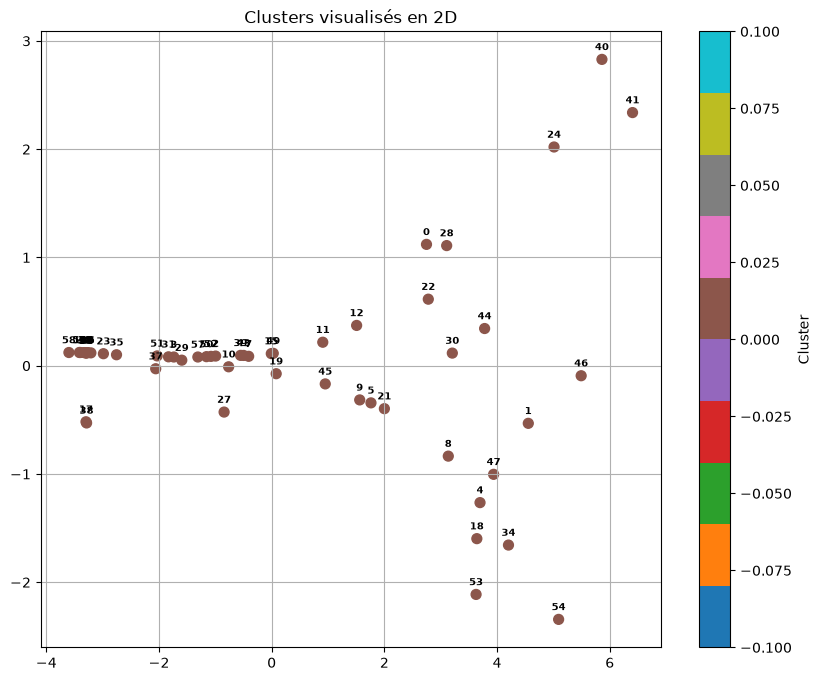

In [34]:
X = X_mds
labels = labels_agglo

fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=50)
plt.colorbar(scatter, label='Cluster')

for i, (x, y) in enumerate(X[:, :2]):
    ax.annotate(str(i), (x, y), fontsize=7, fontweight='bold', ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

plt.title('Clusters visualisés en 2D')
plt.grid()
plt.show()

In [35]:
clusters = get_slides_cluster(labels, slides_annot, slides_tumor)
clusters['cluster'].unique()

array([1, 0])

In [20]:
from bokeh.plotting import figure, output_notebook, show, reset_output
from bokeh.models import HoverTool, ColumnDataSource
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from bokeh.embed import file_html
from bokeh.resources import CDN
import base64
from bokeh.plotting import figure, output_notebook, show, output_file, save
from bokeh.models import HoverTool, ColumnDataSource, LinearColorMapper, Legend
from bokeh.palettes import Category10_10, Inferno256 
from bokeh.transform import factor_cmap
from bokeh.palettes import Set1_9, Category20, Turbo256

In [23]:
def composite_to_base64_transparent(composite_img, tolerance=90):
    """
    Prend l'image composite NumPy, rend le fond blanc transparent,
    et encode en Base64 PNG pour Bokeh.
    """
    # 1. Conversion en format compatible OpenCV (0-255, uint8)
    # Assumons que make_composite retourne des floats 0-1
    img_uint8 = (composite_img * 255).astype(np.uint8)
    
    # 2. Conversion RGB (Matplotlib) -> BGRA (OpenCV + Alpha)
    img_bgra = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2BGRA)
    
    # 3. Transparence : Masque pour le fond "presque blanc"
    lower_white = 255 - tolerance
    bg_mask = (img_bgra[:, :, 0] >= lower_white) & \
              (img_bgra[:, :, 1] >= lower_white) & \
              (img_bgra[:, :, 2] >= lower_white)
    
    img_bgra[bg_mask, 3] = 0  # Canal Alpha à 0 (transparent)
    
    # 4. Redimensionnement pour la performance de l'infobulle (optionnel)
    img_bgra = cv2.resize(img_bgra, (200, 200), interpolation=cv2.INTER_AREA)

    # 5. Encodage en PNG Base64
    _, buffer = cv2.imencode('.png', img_bgra)
    b64_string = base64.b64encode(buffer).decode('utf-8')
    
    return f"data:image/png;base64,{b64_string}"

# A. Génération des images composites et conversion Base64
b64_images = []
for sld in slides_tumor:
    masks_dict = sld[1]
    composite = make_composite(masks_dict)
    b64 = composite_to_base64_transparent(composite, tolerance=30)
    b64_images.append(b64)

# C. Création du DataFrame
df = pd.DataFrame({
    'x': X[:, 0],
    'y': X[:, 1],
    'cluster': labels,
    'cluster_str': labels.astype(str), # Bokeh préfère les chaînes pour les couleurs catégorielles
    'img_data': b64_images
})

# --- 4. Visualisation Bokeh ---

reset_output()
output_notebook()
datasource = ColumnDataSource(df)

# 1. Extraire et trier les clusters en tant que chaînes de caractères
unique_clusters = sorted(df['cluster_str'].unique())

# 2. Choisir une palette beaucoup plus vive
if len(unique_clusters) <= 9:
    # Set1 est extrêmement saturée et contrastée
    palette = Set1_9[:max(3, len(unique_clusters))] 
elif len(unique_clusters) <= 20:
    palette = Category20[len(unique_clusters)]
else:
    # Turbo256 est beaucoup plus vif qu'Inferno. 
    # On échantillonne la palette pour espacer les couleurs au maximum.
    step = len(Turbo256) // len(unique_clusters)
    palette = [Turbo256[i * step] for i in range(len(unique_clusters))]

# 3. Utiliser factor_cmap (idéal pour les catégories) au lieu de LinearColorMapper
color_mapper = factor_cmap('cluster_str', palette=palette, factors=unique_clusters)

plot = figure(
    title="Visualisation des Clusters d'Images",
    tools="pan,wheel_zoom,reset,box_zoom,save",
    width=1050,
    height=700,
    background_fill_color="#fafafa"
)

# Dessiner les points
scatter = plot.scatter(
    'x', 'y', 
    source=datasource, 
    size=10, 
    alpha=0.90, # Augmenté de 0.7 à 0.85 pour rendre la couleur plus dense
    fill_color=color_mapper,
    line_color="black", # Ajouter une fine ligne blanche fait "poper" les couleurs
    line_width=0.5,
    legend_field='cluster_str',
)

legend = plot.legend[0]
plot.add_layout(legend, 'right')
legend.title = 'Clusters'
legend.click_policy = 'hide'

# Configuration de l'infobulle HTML (avec transparence)
hover = HoverTool(tooltips="""
    <div style="background-color: rgba(255, 255, 255, 0.9); padding: 10px; border-radius: 8px; border: 1px solid #ccc;">
        <div><strong>Cluster:</strong> @cluster</div>
        <div style="margin-top: 5px;">
            <img src="@img_data" alt="Composite preview" style="max-width: 200px; max-height: 200px; display: block; border: 1px solid #eee;">
        </div>
    </div>
""")

plot.add_tools(hover)
show(plot)

html_content = file_html(plot, CDN, "Visualisation des clusters d'images")
with open("interactive_clusters.html", "w", encoding="utf-8") as f:
    f.write(html_content)



Loading BokehJS ...

For n_clusters = 2 The average silhouette_score is : 0.6016974374490467
For n_clusters = 3 The average silhouette_score is : 0.5433880026660353
For n_clusters = 4 The average silhouette_score is : 0.5997469235244388
For n_clusters = 5 The average silhouette_score is : 0.5475430809620065
For n_clusters = 6 The average silhouette_score is : 0.5377675588510523


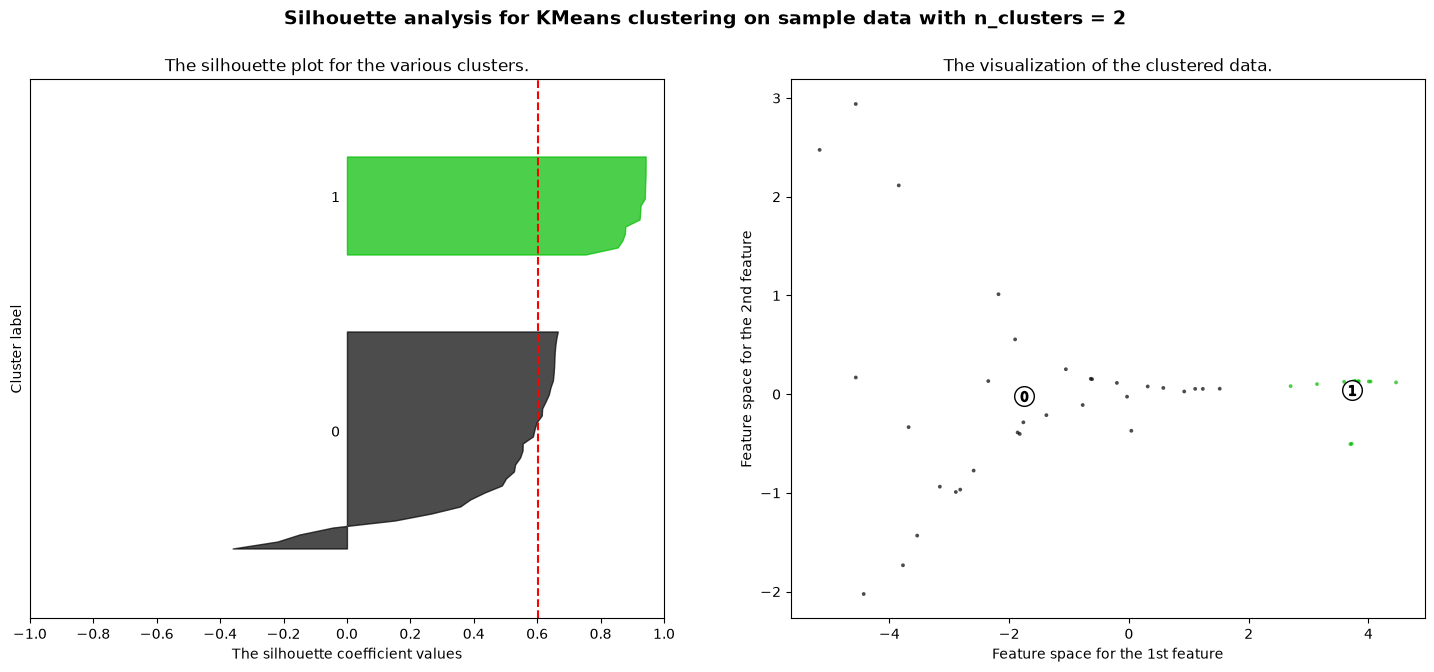

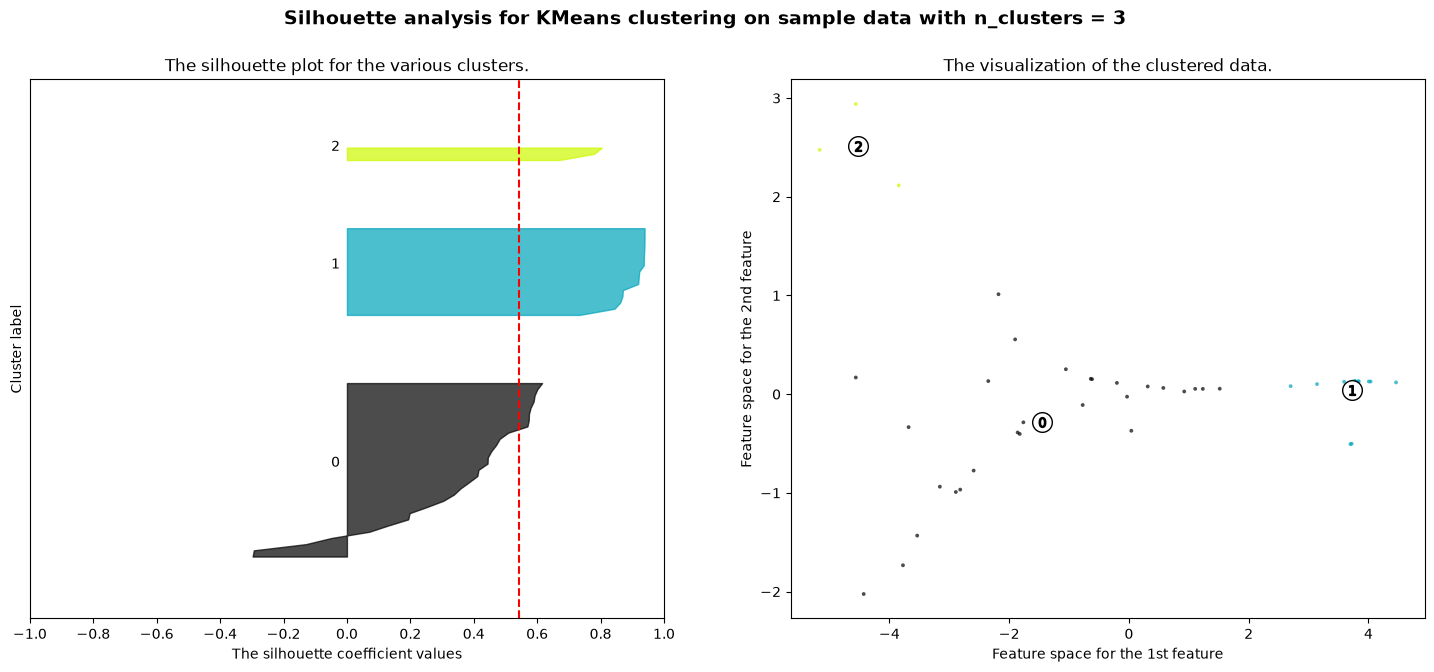

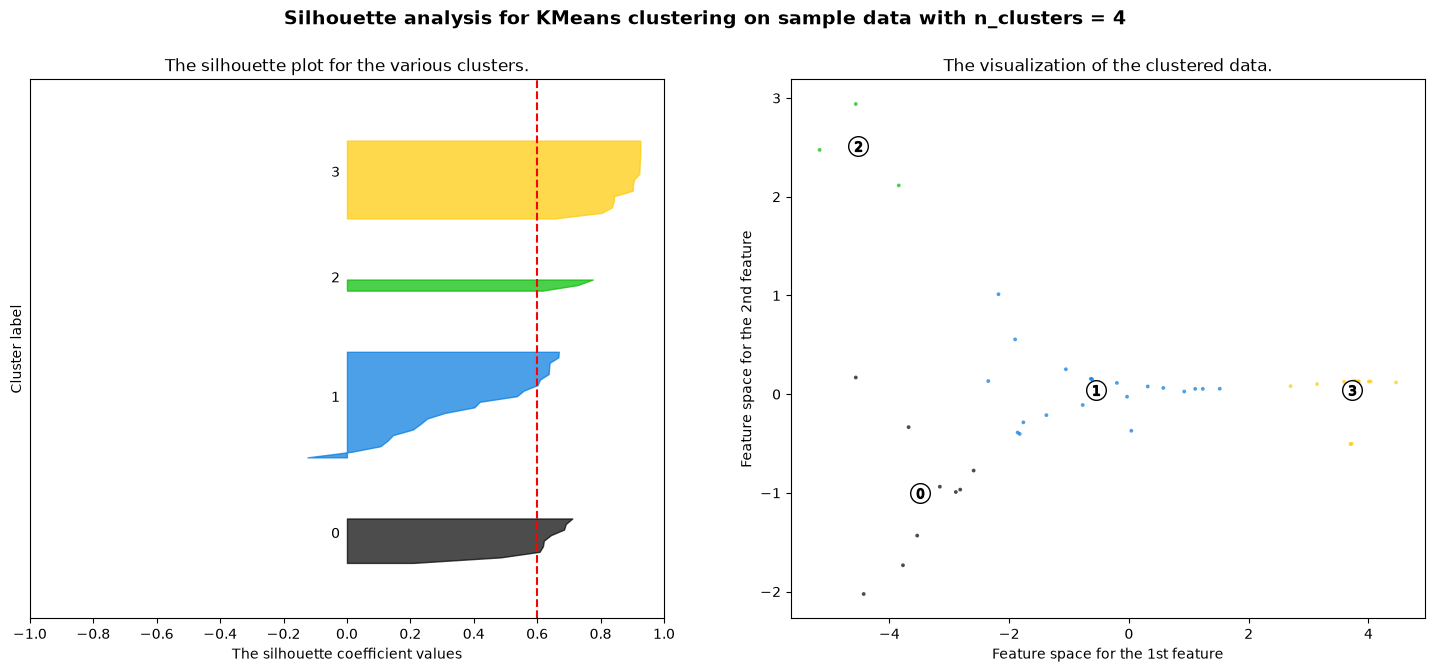

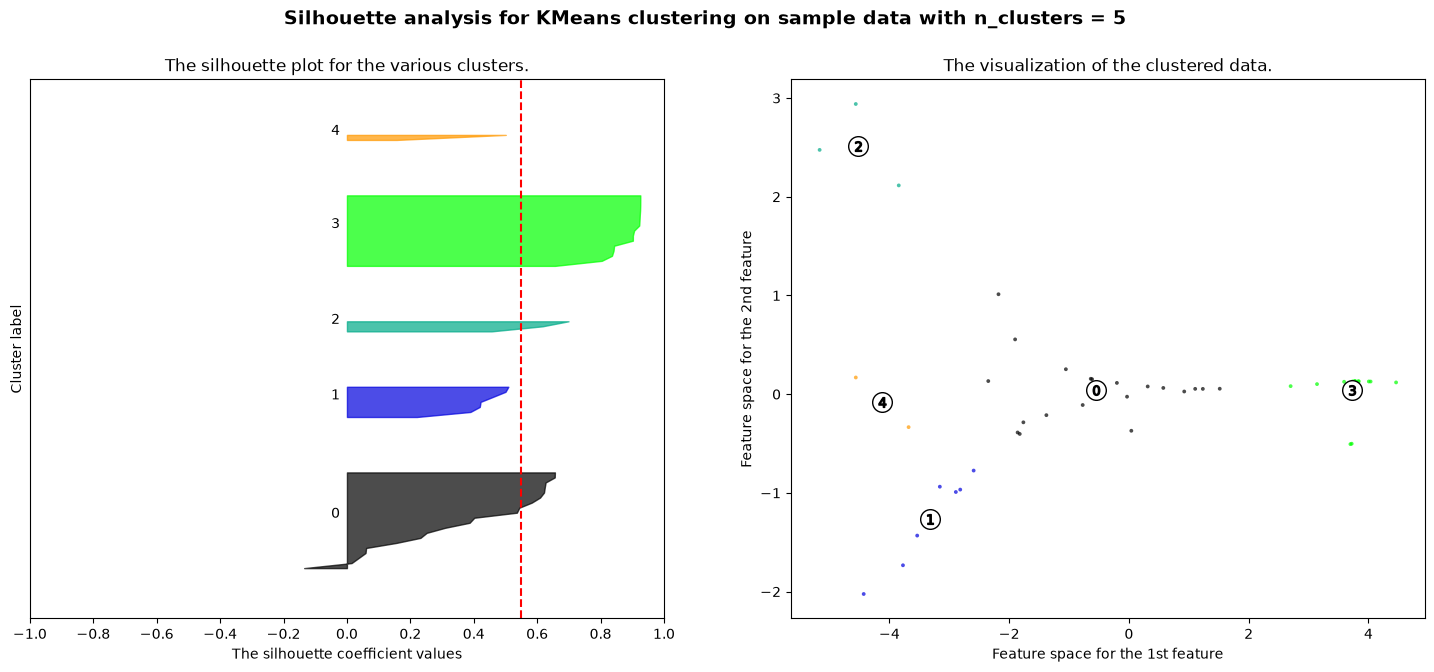

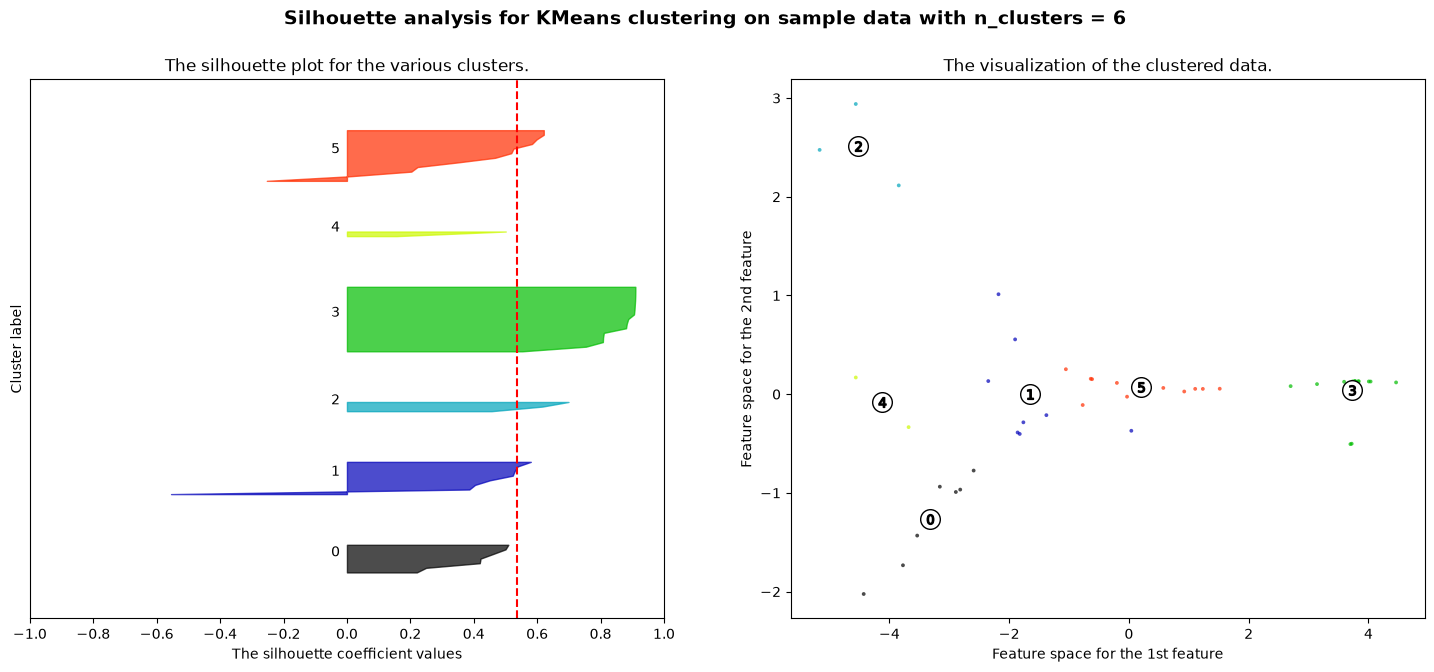

In [328]:
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples, silhouette_score


range_n_clusters = [2, 3, 4, 5, 6]

dist_matrix = dist_matrix2

mds = MDS(n_components=2, metric='precomputed', random_state=42, n_init=1, init='classical_mds')
X = mds.fit_transform(dist_matrix)

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    clustering = AgglomerativeClustering(
        n_clusters=n_clusters,
        metric='precomputed',
        linkage='average',
    )
    cluster_labels = clustering.fit_predict(dist_matrix)

    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks(np.arange(-1, 1.2, 0.2))

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X[:, 0], X[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # # Labeling the clusters
    centers = centers = np.array([X[cluster_labels== i].mean(axis=0) for i in np.unique(cluster_labels)])
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

In [ ]:
def plot_cluster_grid(slides_tumor, cluster_labels):
    unique_labels = np.unique(cluster_labels)

    for l in unique_labels:
        cluster_slides = [sld for sld, label in zip(slides_tumor, cluster_labels)
                        if label==l]
        plot_slide_grid(cluster_slides, figsize=(8,8), title=f"cluster-{l}")

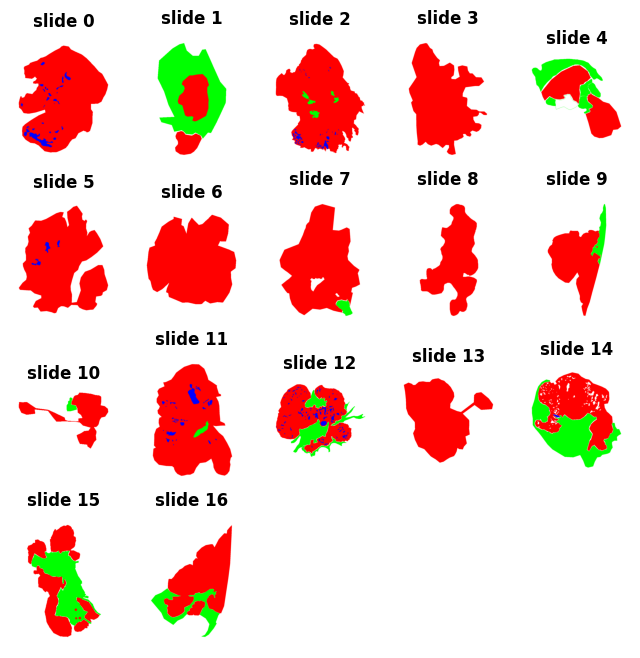

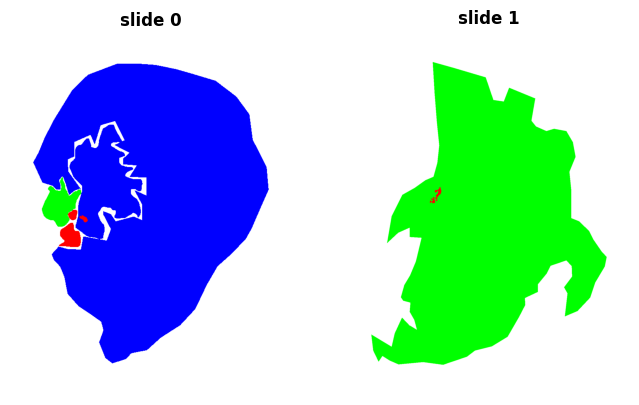

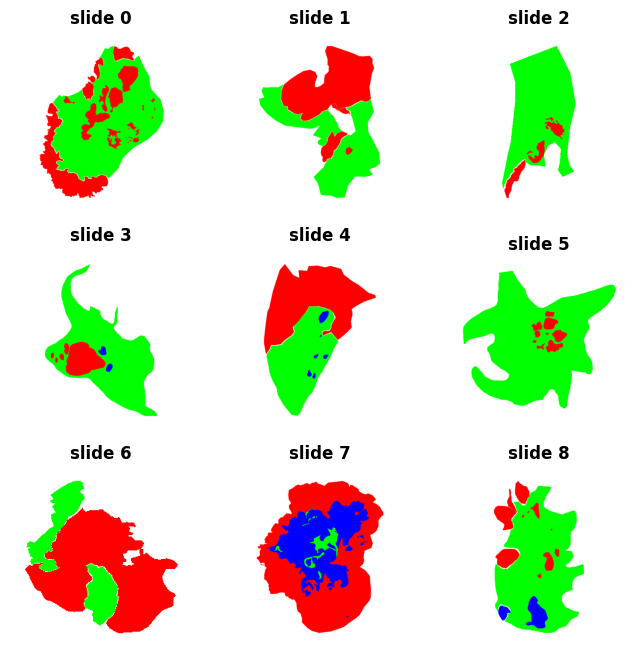

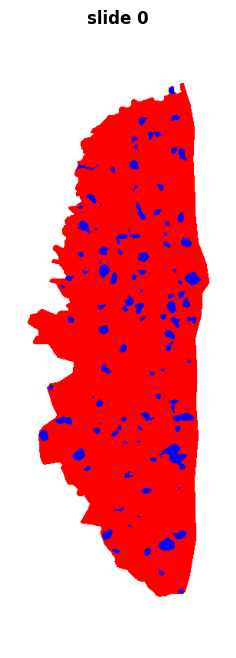

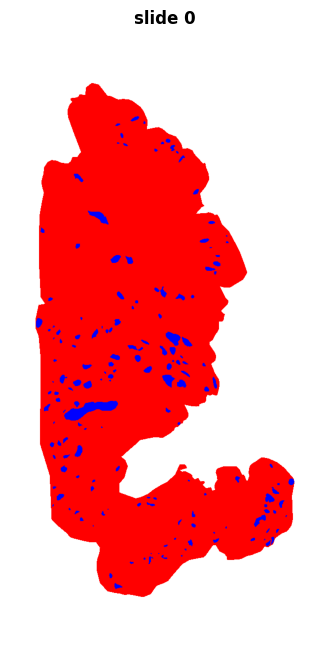

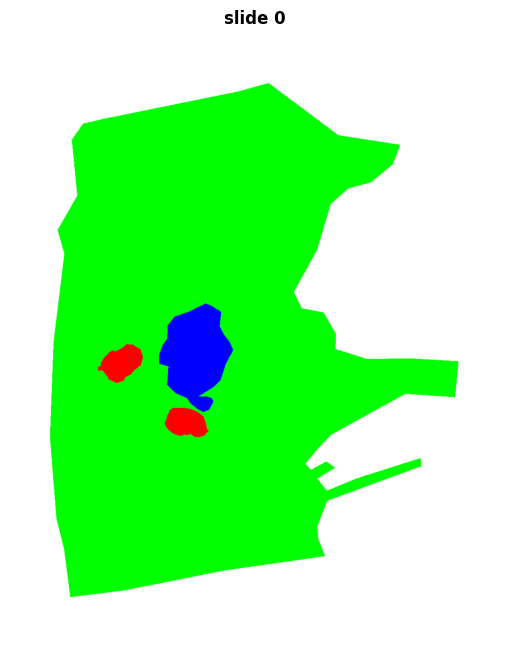

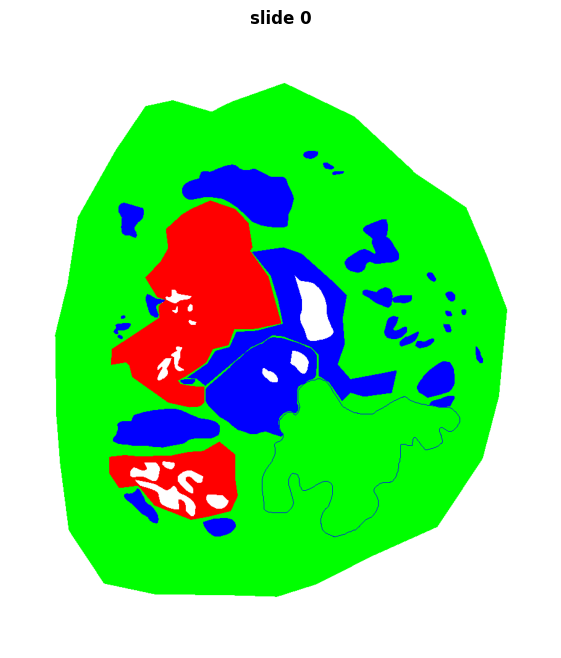

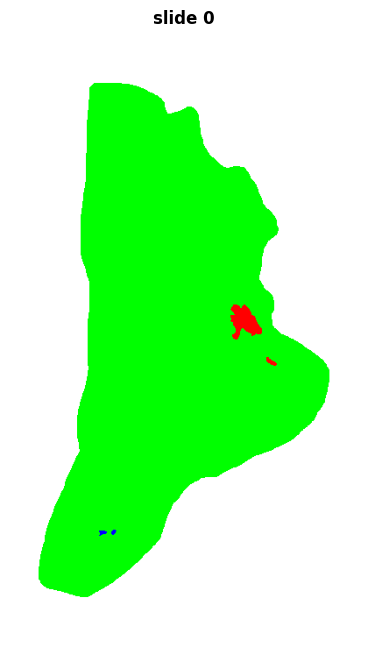

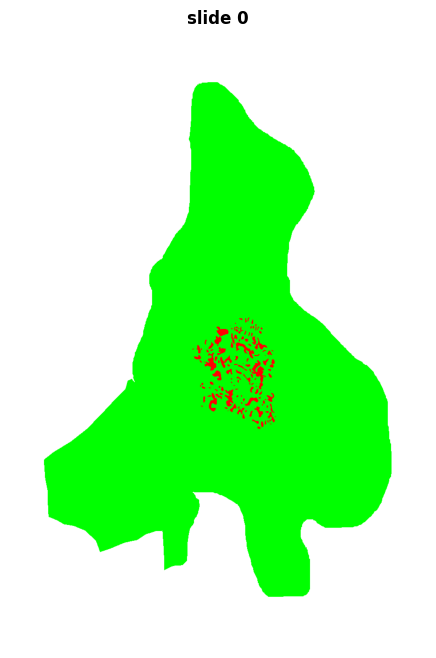

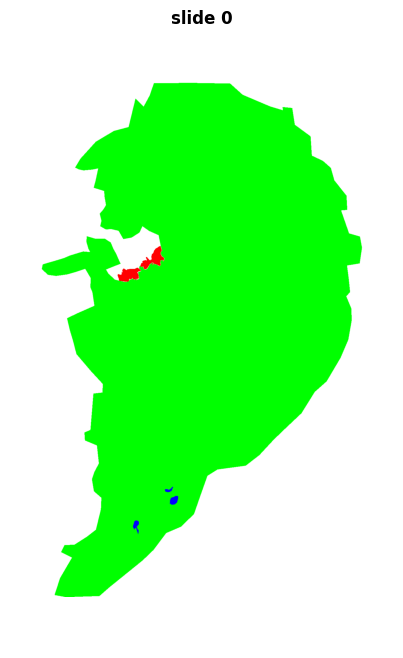

In [ ]:
plot_cluster_grid(slides_tumor, labels)

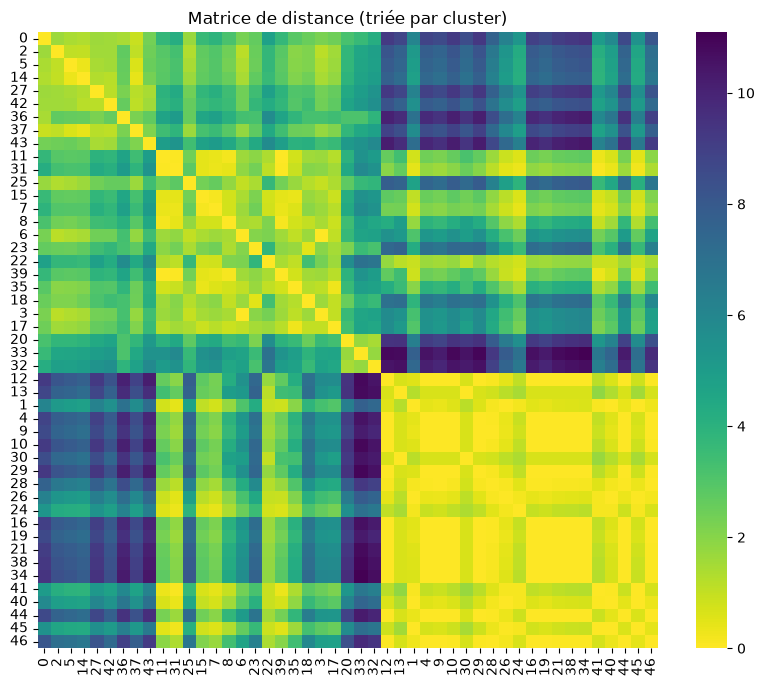

In [447]:
order = np.argsort(labels)
plt.figure(figsize=(10, 8))
sns.heatmap(
    dist_matrix[order][:, order],
    cmap='viridis_r',
    xticklabels=order,
    yticklabels=order,
)
plt.title('Matrice de distance (triée par cluster)')

plt.show()

In [24]:
mds.stress_

np.float64(895.3264759134252)

In [ ]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

In [ ]:
plot_dendrogram(clustering, truncate_mode="level", p=6)

In [ ]:
dist_2d = pairwise_distances(X)

orig = dist_matrix
proj = mds.dissimilarity_matrix_

plt.scatter(orig, proj, alpha=0.5)
plt.plot([orig.min(), orig.max()], [orig.min(), orig.max()], 'r--')
plt.xlabel("Distances originales")
plt.ylabel("Distances projetées")
plt.title("Shepard plot — idéalement tous les points sur la diagonale")

In [ ]:
score = silhouette_score(dist_matrix, labels_agglo, metric='precomputed')
print(f"Silhouette : {score:.3f}")  # Entre -1 et 1, > 0.5 = bons clusters

Silhouette : 0.447


# Processing patient data

### Loading

In [26]:
raw_data = pd.read_excel(PATH_PATIENT_DATA)

vars_clust = (
    'Patient',
    #'Sexe',
    'Tabagisme avant le diagnostic (oui/jamais)',
    'Age au diagnostic',                                          #num
    'Type histologique',
    'Stade clinique',
    'PDL1',                                                       #num
    'Molecule n°1',
    'Molecule n°2',
    'Molecule n°3',
    'Nombre de cycle de chimio-immunothérapie',                   #num
)

data_c = raw_data.loc[:, vars_clust]

### Data cleaning

In [27]:
def clean_data_clust(df):
    clean_df = df.copy()
    dropped_samples = 0

    clean_df['Patient'] = clean_df['Patient'].str.strip()
    patient_indices = clean_df['Patient'].dropna().index
    clean_df = clean_df.iloc[patient_indices, :]

    missing_val_molecules = [
        'Molecule n°2',
        'Molecule n°3'
    ]
    for col in missing_val_molecules:
        empty_val = clean_df[col] == '.'
        clean_df.loc[empty_val, col] = -1 # new label when the molecule is not used.

    missing_val_feats = [
        'Nombre de cycle de chimio-immunothérapie',
        'Stade clinique',
        'Tabagisme avant le diagnostic (oui/jamais)',
        'Age au diagnostic',
        'Molecule n°1',
        'Molecule n°2',
        'Molecule n°3',
    ]

    for col in missing_val_feats:
        missing_val = pd.to_numeric(
            clean_df[col], errors='coerce'
        ).isna()
        print(f"Cleaning... {col}")
        print(f"Drop samples = {np.sum(missing_val)}  {clean_df['Patient'].values[missing_val]}")
        clean_df.drop(clean_df.index[missing_val], inplace=True)
        dropped_samples += np.sum(missing_val)

    clean_df.reset_index(inplace=True, drop=True)

    vars_num = [
        'Age au diagnostic',
        'PDL1', 
        'Nombre de cycle de chimio-immunothérapie', 
    ]
    vars_cat = [v for v in clean_df.columns if v not in vars_num]

    clean_df[vars_cat] = clean_df[vars_cat].astype('object') #or category ?

    print(f"\nTotal dropped samples = {dropped_samples}")

    return clean_df

def clean_data_desc(clean_df):
    pass

In [36]:
new_data_c = clean_data_clust(data_c)
new_data_c = new_data_c.merge(clusters, how='inner', left_on='Patient', right_on='id-patient')
new_data_c.drop(labels=['Patient', 'id-patient'], axis=1, inplace=True)

X_raw = new_data_c.loc[:, new_data_c.columns[:-1]]
y = new_data_c.loc[:, 'cluster'].to_numpy()
print(f"X_raw shape : {X_raw.shape}")

vars_num = [
        'Age au diagnostic',
        'PDL1', 
        'Nombre de cycle de chimio-immunothérapie', 
]
vars_cat = [v for v in X_raw.columns if v not in vars_num]

# preprocessor = ColumnTransformer(transformers=[
#     ('num', StandardScaler(), vars_num),
#     ('cat', OneHotEncoder(drop='first', sparse_output=False), vars_cat),
# ])
# X = preprocessor.fit_transform(X_raw)
# #X = VarianceThreshold(threshold=0.0).fit_transform(X)
# feats_name = preprocessor.get_feature_names_out()
# print(f"X shape : {X.shape}")


# X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True, test_size=0.3, stratify=y)

Cleaning... Nombre de cycle de chimio-immunothérapie
Drop samples = 6  <StringArray>
['25P12057', '25P27813', '25P29230', '25P32590', '25P36143', '26P2368']
Length: 6, dtype: str
Cleaning... Stade clinique
Drop samples = 9  <StringArray>
['24P38890', '24P39911', '24P42309',  '25P3614', '25P19910', '25P23184',
 '25P36953', '25P44865',  '26P2581']
Length: 9, dtype: str
Cleaning... Tabagisme avant le diagnostic (oui/jamais)
Drop samples = 0  <StringArray>
[]
Length: 0, dtype: str
Cleaning... Age au diagnostic
Drop samples = 1  <StringArray>
['25P6666']
Length: 1, dtype: str
Cleaning... Molecule n°1
Drop samples = 0  <StringArray>
[]
Length: 0, dtype: str
Cleaning... Molecule n°2
Drop samples = 0  <StringArray>
[]
Length: 0, dtype: str
Cleaning... Molecule n°3
Drop samples = 0  <StringArray>
[]
Length: 0, dtype: str

Total dropped samples = 16
X_raw shape : (71, 9)


### Data analysis

In [37]:
classes, counts = np.unique(y, return_counts=True)
for cls, c in zip(classes, counts):
    print(f"Classe {cls}: {c} samples")

Classe 0: 22 samples
Classe 1: 49 samples


In [38]:
corr = np.corrcoef(X_train, y_train, rowvar=False)
plt.matshow(corr)
plt.colorbar();

NameError: name 'X_train' is not defined

In [20]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 191 stored elements and shape (39, 17)>

In [338]:
corr_strength = np.abs(corr[-1, :-1])
indices = np.argsort(corr_strength)[::-1]
k = 5
print(f"Top {k} strongest correlated features")
for i in range(k):
    if np.isnan(corr_strength[indices[i]]):
        continue
    print(f"{i+1}. {feats_name[indices[i]]}, corr = {corr_strength[indices[i]]:.2f}")

Top 5 strongest correlated features
1. num__PDL1, corr = 0.42
2. cat__Stade clinique_2, corr = 0.38
3. cat__Molecule n°2_1, corr = 0.35
4. cat__Type histologique_1.0, corr = 0.29
5. cat__Molecule n°2_0, corr = 0.26


Text(0.5, 1.0, 'Explained variance by pca components')

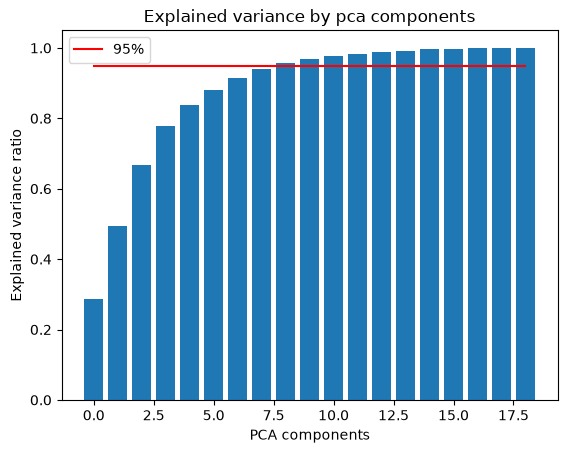

In [339]:
pca = PCA().fit(X)
plt.bar(np.arange(pca.n_components_), np.cumsum(pca.explained_variance_ratio_))
plt.plot(np.arange(pca.n_components_), np.ones(pca.n_components_)*0.95, c='red', label='95%')
plt.legend()

plt.xlabel('PCA components')
plt.ylabel('Explained variance ratio')
plt.title('Explained variance by pca components')

In [ ]:
k = 7
X_pca = PCA(n_components=k).fit_transform(X)

__Analyse__:
En utilisant les axes issus de l'ACP on n'obtient pas un meilleur score de classification (f1_macro ~ 0.67)

In [338]:
import textwrap

In [ ]:
def plot_feat_distribution(X, y, figsize=None):
    _, n_feats = X.shape

    if figsize:
        plt.figure(figsize=figsize)
    i = 1
    for c in range(2):
        for col in X:
            plt.subplot(2, n_feats, i)
            plt.hist(X[y==c][col])
            plt.xlabel("Values")
            plt.ylabel("Counts")
            title = textwrap.fill(f"{col}(y={c})", width=25)
            plt.title(title)
            i += 1
    """ plt.subplots_adjust(
        left=0.1, bottom=0.1, right=1, 
        top=0.9, wspace=0.4,hspace=0.4
    ) """
    plt.tight_layout()
    plt.suptitle("Distribution des variables", y=1.1)


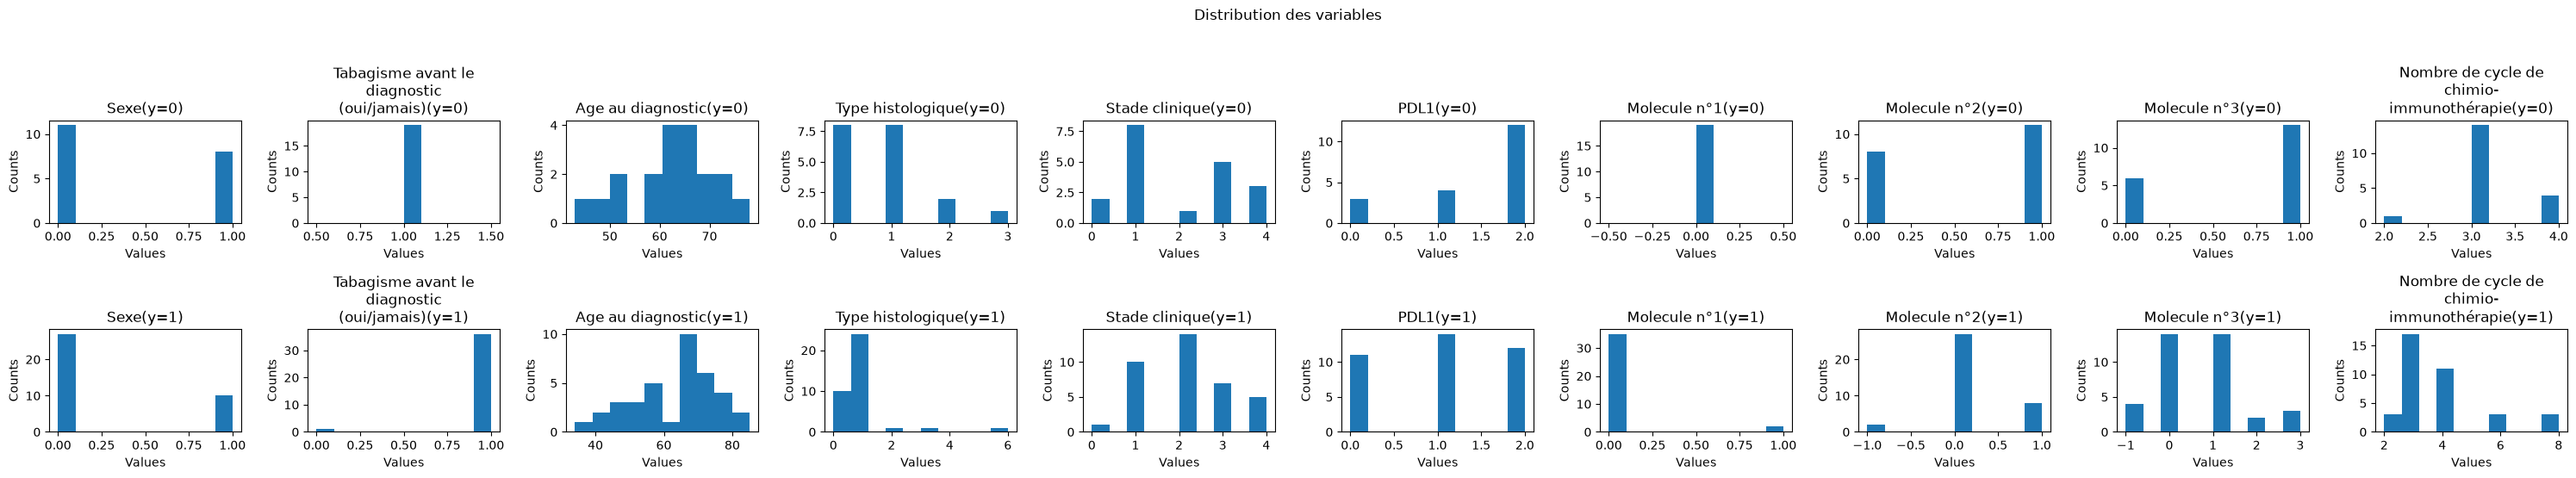

In [364]:
plot_feat_distribution(X_raw, y, figsize=(30,5))

__Analyse__:  
Il y a des variables dont la distribution reste la même quelque soit la classe :  
- Sexe, Tabagisme, PDL1, Type de TTT neoadjuvant, Molecule n°1, nb cycle de maintenance

In [325]:
def get_class_weight(y, norm=True, square_root=True):
    labels, label_count = np.unique(y, return_counts=True)
    total_pxl = np.sum(label_count)
    freq = {int(l): count/total_pxl for l, count in zip(labels, label_count)}
    inv_feq = {int(l): 1/freq[l] for l in labels}
    if norm:
        if square_root:
            weights = {l: np.sqrt(i)/np.sqrt(list(inv_feq.values())).mean()
                       for l, i in inv_feq.items()}
        else:
            weights = {l: i/np.array(list(inv_feq.values())).mean()
                       for l, i in inv_feq.items()}
    else:
        weights = inv_feq
    return weights

In [326]:
weights = get_class_weight(y_train, square_root=False)
weights

{0: np.float64(1.3636363636363638), 1: np.float64(0.6363636363636365)}

In [440]:
rf = RandomForestClassifier(n_estimators=100, random_state=0, class_weight=weights)
gb = GradientBoostingClassifier(
    n_estimators=100,
    loss='log_loss',
    random_state=11,
)

In [441]:
clf = rf
loo = LeaveOneOut()
y_true, y_pred = [], []

for train_idx, test_idx in loo.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    clf.fit(X_train, y_train)
    
    prediction = clf.predict(X_test)
    
    y_true.append(y_test[0])
    y_pred.append(prediction[0])

print(classification_report(y_true, y_pred, zero_division=np.nan))

              precision    recall  f1-score   support

           0       0.67      0.70      0.68        20
           1       0.86      0.84      0.85        43

    accuracy                           0.79        63
   macro avg       0.76      0.77      0.76        63
weighted avg       0.80      0.79      0.79        63



In [420]:
clf.feature_importances_

array([0.2939033 , 0.05815635, 0.19491152, 0.07768964, 0.06264993,
       0.09423659, 0.21845266])

In [342]:
def feat_selection(X, y, X_train, y_train, feats_name, selector='SelectKBest'):
    n_feats = X.shape[1]
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)
    rf = RandomForestClassifier(n_estimators=100, random_state=11)
    gb = GradientBoostingClassifier(
        n_estimators=100,
        loss='log_loss',
        random_state=11,
    )
    clf = rf

    if selector.lower() == 'SelectKBest'.lower():
        means = []
        stds = []
        all_selection = []
        for k in range(1, n_feats+1):
            s = SelectKBest(f_classif, k=k)
            with warnings.catch_warnings(), np.errstate(divide='ignore', invalid='ignore'):
                warnings.simplefilter("ignore")
                s.fit(X, y)
                feats_selected = s.get_support()
                scores = cross_val_score(clf, X[:, feats_selected], y, cv=cv, scoring='f1_macro')
            means.append(scores.mean())
            stds.append(scores.std())
            all_selection.append(feats_selected)

        plt.errorbar(np.arange(1, n_feats+1, 1), means, stds)
        idx_best = np.argmax(means)
        print(f"Best selection : {feats_name[all_selection[idx_best]]} \n k = {len(feats_name[all_selection[idx_best]])} \n f1_macro = {means[idx_best]}")

    elif selector.lower() == 'RFECV'.lower():
        with warnings.catch_warnings(), np.errstate(divide='ignore', invalid='ignore'):
            warnings.simplefilter("ignore")
            s = RFECV(clf, cv=cv, scoring='f1_macro')
            s.fit(X, y)
        means = s.cv_results_['mean_test_score']
        stds = s.cv_results_['std_test_score']
        plt.errorbar(s.cv_results_['n_features'], means, stds)
        idx_best = np.argmax(means)
        print(f"Best selection : {feats_name[s.support_]} \n k = {len(feats_name[s.support_])} \n f1_macro = {means.max()}")
    else:
        return None
    plt.xlabel('k best features')
    plt.ylabel('f1_macro')
    plt.title('k best features evaluation')
    plt.grid()
    plt.show()


Best selection : ['cat__Stade clinique_2' 'cat__Molecule n°2_0' 'cat__Molecule n°2_1'] 
 k = 3 
 f1_macro = 0.765923386898619


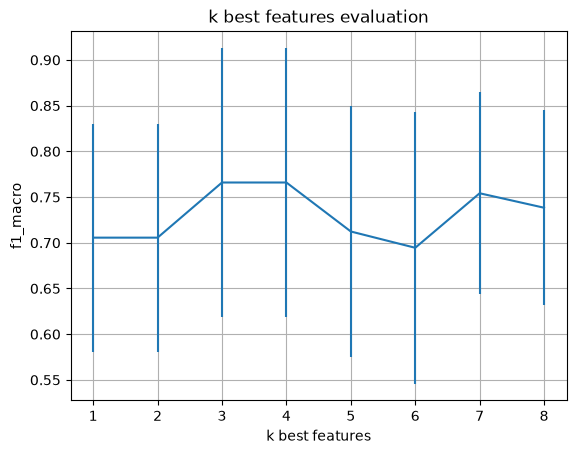

In [442]:
feat_selection(X, y, X_train, y_train, feats_name, selector='SelectKBest')

Best selection : ['num__Age au diagnostic' 'num__PDL1' 'cat__Stade clinique_2'
 'cat__Molecule n°2_1'] 
 k = 4 
 f1_macro = 0.7771512113617376


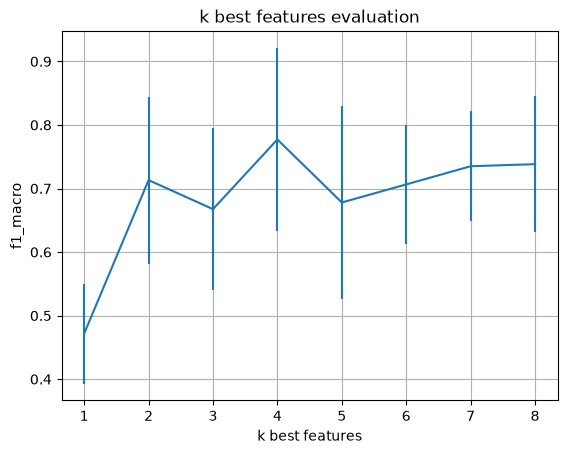

In [443]:
feat_selection(X, y, X_train, y_train, feats_name, selector='RFECV')

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
def get_label_patient(label, distribution_data, data_light):
    df_light = {row['Patient'].strip(): row.drop('Patient').to_dict() for i, row in data_light.iterrows()}
    labels = [df_light[id_patient(sld_name)][label] for sld_name in distribution_data 
              if id_patient(sld_name) in df_light]
    return labels

In [ ]:
distribution_data_filtered = {k: v for k, v in distribution_data.items() if id_patient(k) in data_light['Patient'].values}

## Data analysis

In [39]:
import warnings


In [40]:
warnings.filterwarnings('ignore')
#warnings.resetwarnings()

In [42]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), vars_num),
        ("cat", OneHotEncoder(
            min_frequency=0.05,
            handle_unknown="ignore",
        ), vars_cat),
    ]
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("select", SelectKBest(score_func=f_classif)),
    ("clf", LogisticRegression(
        l1_ratio=1, solver="liblinear",
        class_weight="balanced", max_iter=1000
    )),
])

param_grid = {
    "select__k": [2, 3, 4, 5, 6, 8],
    "clf__C": [0.01, 0.1, 1, 10],
}

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipeline, param_grid,
    scoring="f1_macro", cv=inner_cv, n_jobs=-1
)

outer_cv = LeaveOneOut()

y_pred_nested = cross_val_predict(grid, X_raw, y, cv=outer_cv, n_jobs=-1)

print("=== Rapport de classification (nested CV, honnête) ===")
print(classification_report(y, y_pred_nested))


simple_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("select", SelectKBest(score_func=f_classif, k=5)),
    ("clf", LogisticRegression(
        l1_ratio=1, solver="liblinear",
        C=10, class_weight="balanced", max_iter=1000
    )),
])

score, perm_scores, pvalue = permutation_test_score(
    simple_pipeline, X_raw, y,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring="f1_macro", n_permutations=1000, n_jobs=-1, random_state=42
)

print(f"\n=== Test de permutation ===")
print(f"F1-macro observé          : {score:.3f}")
print(f"F1-macro moyen (hasard)   : {perm_scores.mean():.3f}")
print(f"p-value                  : {pvalue:.4f}")


selected_counter = Counter()

for train_idx, _ in outer_cv.split(X_raw, y):
    X_train, y_train = X_raw.iloc[train_idx], y[train_idx]
    grid.fit(X_train, y_train)
    mask = grid.best_estimator_.named_steps["select"].get_support()
    encoded_feature_names = grid.best_estimator_.named_steps["preprocessor"].get_feature_names_out()
    for var in encoded_feature_names[mask]:
        selected_counter[var] += 1

print("\n=== Fréquence de sélection par variable (sur 56 folds) ===")
for var, count in selected_counter.most_common():
    print(f"  {var}: {count}/56 ({100*count/56:.0f}%)")


/home/jaffolabi/Documents/lung_map/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/jaffolabi/Documents/lung_map/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/jaffolabi/Documents/lung_map/.venv/lib/python3.11/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [3] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/jaffolabi/Documents/lung_map/.venv/lib/python3.11/site-packages/sklearn/utils/parallel.py:14

=== Rapport de classification (nested CV, honnête) ===
              precision    recall  f1-score   support

           0       0.38      0.50      0.43        22
           1       0.74      0.63      0.68        49

    accuracy                           0.59        71
   macro avg       0.56      0.57      0.56        71
weighted avg       0.63      0.59      0.60        71


=== Test de permutation ===
F1-macro observé          : 0.565
F1-macro moyen (hasard)   : 0.473
p-value                  : 0.1339

=== Fréquence de sélection par variable (sur 56 folds) ===
  cat__Molecule n°2_0: 71/56 (127%)
  cat__Molecule n°2_1: 71/56 (127%)
  cat__Stade clinique_2: 60/56 (107%)
  cat__Type histologique_1.0: 52/56 (93%)
  cat__Molecule n°3_1: 46/56 (82%)
  num__Nombre de cycle de chimio-immunothérapie: 29/56 (52%)
  cat__Molecule n°3_3: 17/56 (30%)
  cat__Type histologique_infrequent_sklearn: 15/56 (27%)
  cat__Molecule n°3_-1: 14/56 (25%)
  cat__Stade clinique_infrequent_sklearn: 5/56 (9%)

In [18]:
perm_scores.shape

(1000,)

In [41]:
grid.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('select', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Tabagisme avant le diagnostic (oui/jamais)','Age au diagnostic', 'Type histologique',...,'Molecule n°2','Molecule n°3', 'Nombre de cycle de chimio-immunothérapie']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-spe

## Clustering - Optimal Transport

In [ ]:
grid = np.linspace(0, 2, 100)
X = np.array([
    dist['kde']['center'](grid) 
    for _, dist in distribution_data_local.items()
])

for row in X:
    row /= row.sum()

X = X.T

Début du clustering...
Convergence atteinte à l'itération 5.


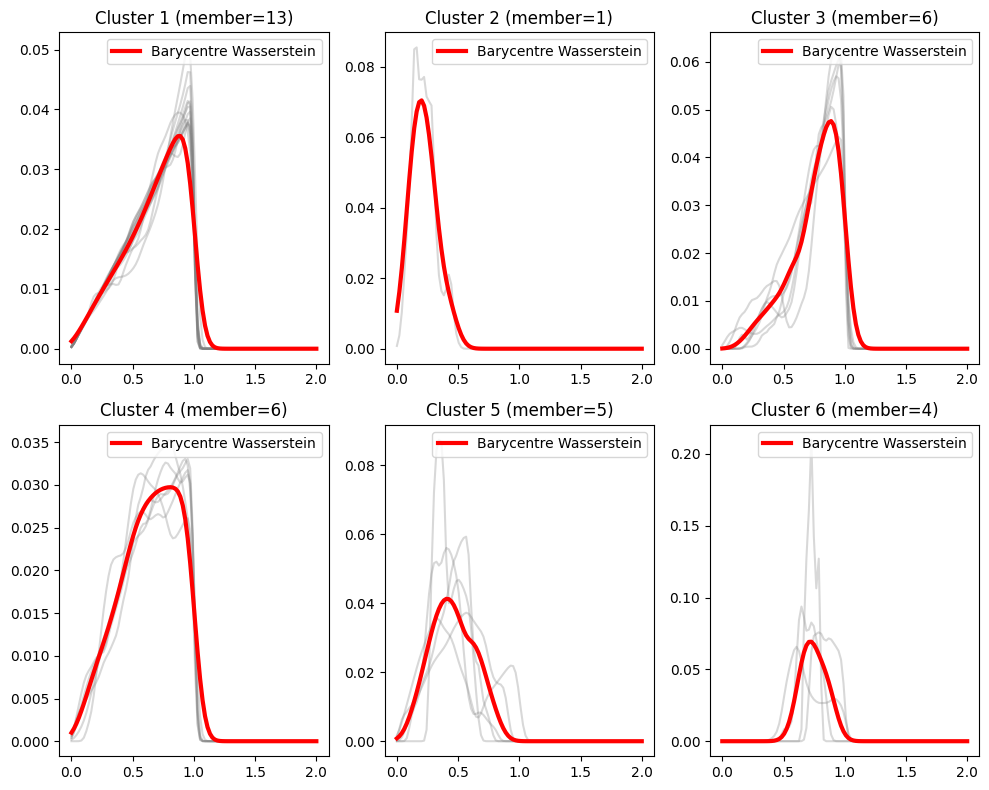

In [ ]:
d, N = X.shape
K = 6                  # Nombre de clusters
max_iter = 50          # Nombre maximum d'itérations
reg = 2e-3             # Paramètre de régularisation entropique (Sinkhorn)
M = ot.dist(grid.reshape((d, 1)), grid.reshape((d, 1)))
M /= np.max(M)
method = 'sinkhorn_log'
# ==========================================
# Algorithme K-Means avec Transport Optimal
# ==========================================
print("Début du clustering...")

init_indices = np.random.choice(N, K, replace=False)
centers = X[:, init_indices].copy()
labels = np.zeros(N)

for iteration in range(max_iter):
    
    # --- ÉTAPE 1 : Assignation ---
    distances = np.zeros((N, K))
    for i in range(N):
        for k in range(K):
            distances[i, k] = ot.sinkhorn2(
                X[:, i], centers[:, k], M, reg, 
                method=method,
            )
            
    new_labels = np.argmin(distances, axis=1)
    
    if np.array_equal(labels, new_labels):
        print(f"Convergence atteinte à l'itération {iteration}.")
        break
    labels = new_labels
    
    # --- ÉTAPE 2 : Mise à jour (Barycentres de Wasserstein) ---
    for k in range(K):
        cluster_data = X[:, labels == k]
        if cluster_data.shape[1] > 0:
            centers[:, k] = ot.bregman.barycenter(
                cluster_data, M, reg,
                method=method
            )

labels_ot_kmeans = labels

# Visualisation
plt.figure(figsize=(10, 8))
cols = math.ceil(math.sqrt(K))
rows = math.ceil(K / cols)
for k in range(K):
    plt.subplot(rows, cols, k+1)
    cluster_data = X[:, labels == k]
    
    # Afficher les distributions du cluster
    for i in range(cluster_data.shape[1]):
        plt.plot(grid, cluster_data[:, i], color='gray', alpha=0.3)
        
    # Afficher le barycentre
    plt.plot(grid, centers[:, k], color='red', linewidth=3, label='Barycentre Wasserstein')
    
    plt.title(f'Cluster {k+1} (member={cluster_data.shape[1]})')
    plt.legend()

plt.tight_layout()
plt.show()

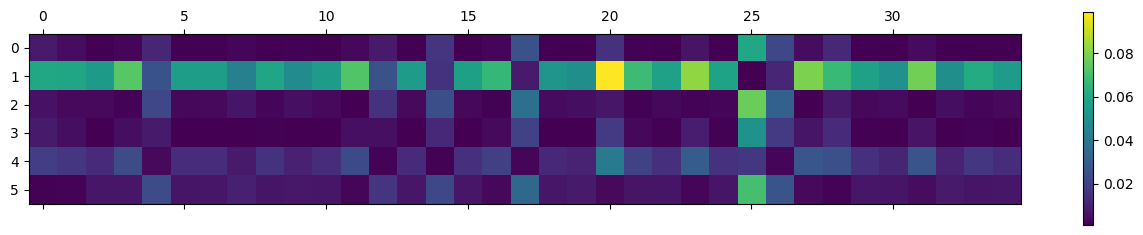

In [ ]:
plt.matshow(distances.T)
plt.colorbar()

In [6]:
def change_orientation(img, action=None):
    match action:
        case "rot90": return np.rot90(img, k=1, axes=(-2, -1))
        case "rot180": return np.rot90(img, k=2, axes=(-2, -1))
        case "rot-90": return np.rot90(img, k=-1, axes=(-2, -1))
        case "flip_h": return np.flip(img, axis=-1)
        case "flip_v": return np.flip(img, axis=-2)
        case _: return img

def assemble_h(img_gauche, img_droite):

    h_max = max(img_gauche.shape[-2], img_droite.shape[-2])
    
    missing_g = h_max - img_gauche.shape[-2]
    missing_d = h_max - img_droite.shape[-2]

    pad_g = [(0,0)] * (img_gauche.ndim - 2) + [(0, missing_g), (0, 0)]
    pad_d = [(0,0)] * (img_droite.ndim - 2) + [(0, missing_d), (0, 0)]
    
    img_g_pad = np.pad(img_gauche, pad_g, mode='constant', constant_values=0)
    img_d_pad = np.pad(img_droite, pad_d, mode='constant', constant_values=0)
    
    return np.concatenate((img_g_pad, img_d_pad), axis=-1)


def assemble_v(img_haut, img_bas):

    w_max = max(img_haut.shape[-1], img_bas.shape[-1])
    
    missing_h = w_max - img_haut.shape[-1]
    missing_b = w_max - img_bas.shape[-1]
    
    pad_h = [(0,0)] * (img_haut.ndim - 2) + [(0, 0), (0, missing_h)]
    pad_b = [(0,0)] * (img_bas.ndim - 2) + [(0, 0), (0, missing_b)]
    
    img_h_pad = np.pad(img_haut, pad_h, mode='constant', constant_values=0)
    img_b_pad = np.pad(img_bas, pad_b, mode='constant', constant_values=0)
    
    return np.concatenate((img_h_pad, img_b_pad), axis=-2)

In [ ]:
# 24P41641
img_g = puzzle_sld['24P41641']['24P41641_26_1']
img_d = puzzle_sld['24P41641']['24P41641_27_1_UTC_13']

img_full = assemble_h(img_g[:, :, :-225], img_d[:, :, 225:])

plt.imshow(img_full[1, :, :])

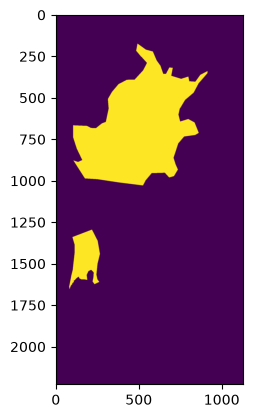

In [46]:
# DS_A02R
img_h = puzzle_sld['DS_A02R']['DS_A02R_03S']
img_b = puzzle_sld['DS_A02R']['DS_A02R_04S']

img_full = assemble_v(img_h, img_b)

plt.imshow(img_full[2, :, :])

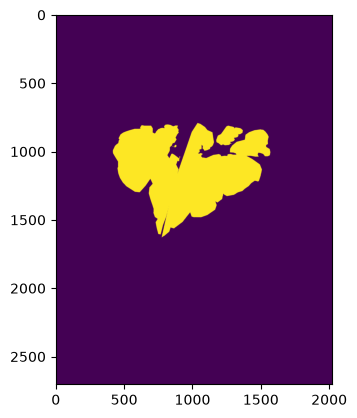

In [6]:
# 25P31438
img_g = puzzle_sld['25P31438']['BC.25P31438.0.tif']
#img_d = puzzle_sld['25P31438']['BC.25P31438.11.6.1']
#img_d = change_orientation(img_d, action="rot180")

#gap = 100
#img_full = assemble_h(img_g[:, :, :-gap], img_d[:, :, gap:])

plt.imshow(img_g[1, :, :])

In [11]:
img_g.shape

(5, 1900, 1218)

In [4]:
puzzle_sld['25P31438'].keys()

dict_keys(['BC.25P31438.11.5.1', 'BC.25P31438.0.tif', 'BC.25P31438.11.6.1'])

In [ ]:
try:
    # On assemble d'abord sur la Largeur (axis=-1)
    ligne_haut = np.concatenate((hg_t, hd_t), axis=-1)
    #ligne_bas = np.concatenate((bg_t, bd_t), axis=-1)

    # On assemble ensuite les deux lignes sur la Hauteur (axis=-2)
    image_reconstituee = np.concatenate((ligne_haut, ligne_bas), axis=-2)

    # ==========================================
    # 4. SAUVEGARDE
    # ==========================================
    tifffile.imwrite("image_finale_parfaite.tif", image_reconstituee)
    print("Succès ! L'image a été reconstituée et sauvegardée.")

except ValueError as e:
    print("Erreur lors de l'assemblage. Vérifiez que les dimensions correspondent après rotation !")
    print(f"Dimensions actuelles : HG={hg_t.shape}, HD={hd_t.shape}, BG={bg_t.shape}, BD={bd_t.shape}")
    print(f"Détail de l'erreur : {e}")